In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import kagglehub
from IPython.display import Audio
import matplotlib.pyplot as plt
from pathlib import Path

2025-11-11 10:39:32.120422: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-11 10:39:32.121389: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-11 10:39:32.124024: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-11 10:39:32.132129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-11 10:39:32.149820: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

## Dataset creation

In [ ]:
SAMPLE_RATE = 22050
DURATION = 10

In [ ]:
# Download the dataset
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")+'/Data/genres_original' 
# which is from https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification (YOU DONT NEED TO DOWNLOAD IT FROM HERE)

# Figure out file locations
dataset_dir = Path(path)
all_files = list(dataset_dir.glob("*/*.wav")) 
all_files = [str(f.relative_to(dataset_dir)) for f in all_files]

# Create dataset
dataset = tf.data.Dataset.from_tensor_slices(all_files) # enable streaming

dataset_dir = str(dataset_dir)
def load_audio(file_path):
    # audio_tensor = tfio.audio.AudioIOTensor(file_path) # AAAAAAAAAAAAAAAAAAAAAFHDSLAFHUSDAGFIOSDBAYF
    # Read the file
    audio_binary = tf.io.read_file(tf.strings.join([dataset_dir, "/", file_path]))
    # Decode WAV (gives waveform tensor and sample rate)
    waveform, sample_rate = tf.audio.decode_wav(audio_binary) 
    waveform = tf.squeeze(waveform, axis=-1)[:SAMPLE_RATE*DURATION] # this is exactly 10 seconds, samples arent exactly the same size
    return file_path, waveform, sample_rate  # return path, waveform and sample rate

dataset = dataset.map(load_audio, num_parallel_calls=tf.data.AUTOTUNE) # not actual autotune, tf tunes the number of threads. remember that map is a lazy process

(<tf.Tensor: shape=(), dtype=string, numpy=b'reggae/reggae.00039.wav'>, <tf.Tensor: shape=(220500,), dtype=float32, numpy=
array([-0.02325439, -0.03765869, -0.03546143, ..., -0.06939697,
       -0.07150269, -0.07650757], dtype=float32)>, <tf.Tensor: shape=(), dtype=int32, numpy=22050>)


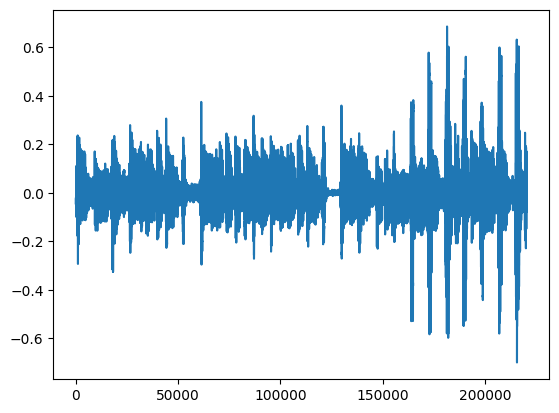

2025-10-29 12:54:30.775267: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# Trying out the dataset

def noisify(audio, maxval=0.2):
    return (audio + tf.random.uniform(audio.shape, minval=-maxval, maxval=maxval)) / 2.0

for tensor in dataset.take(1):
    # look at the tensor. look at it.
    print(tensor)
    audio = tensor[1].numpy()
    rate = tensor[2].numpy()

    # plot waveform
    plt.figure()
    plt.plot(audio)
    plt.show()

    # listen to  r e g g a e, relaaaax, rest your eyes, drink some water
    display(Audio(audio, rate=rate))

    # You must suffer like I have.
    display(Audio(noisify(audio), rate=rate))

In [18]:
# noisify a batch

# take a batch and try it out
batch_size = 4
batched_dataset = dataset.batch(batch_size)

for batch in batched_dataset.take(1):
    filenames, waveforms, sample_rates = batch
    noisy_waveforms = noisify(waveforms)
    loss = tf.reduce_mean(tf.square(waveforms -  noisy_waveforms))
    print(loss)

tf.Tensor(0.007186632, shape=(), dtype=float32)


2025-10-29 12:54:51.029436: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Basic autoencoder


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import Model

In [ ]:
input = layers.Input(shape=(SAMPLE_RATE*DURATION))

x = layers.Con